In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [2]:
# Change these if you want another configuration
CSV_PATH = "clean_data.csv"          # or /content/clean_data.csv in Colab
FRAME_LENGTH = 1000                 # try 500 or 1000
OVERLAP = 0.5                       # try 0.4 or 0.5
TEST_SIZE = 0.25                    # same-dataset split
EPOCHS = 45
BATCH_SIZE = 32
TASK_NAME = "sensor_classification"

In [3]:
df = pd.read_csv(CSV_PATH)
df = df[['environment','test','sensor','sample_index','rssi']].dropna().copy()
df['run_id'] = df['environment'].astype(str) + "_" + df['test'].astype(str) + "_" + df['sensor'].astype(str)
df = df.sort_values(['run_id','sample_index']).reset_index(drop=True)

print(df.head())
print(df['sensor'].value_counts())
print("Total rows:", len(df))

  environment  test    sensor  sample_index  rssi             run_id
0      bridge     1  sensor_1             1   -88  bridge_1_sensor_1
1      bridge     1  sensor_1             2   -87  bridge_1_sensor_1
2      bridge     1  sensor_1             3   -88  bridge_1_sensor_1
3      bridge     1  sensor_1             4   -88  bridge_1_sensor_1
4      bridge     1  sensor_1             5   -88  bridge_1_sensor_1
sensor
sensor_1    450149
sensor_2    385822
Name: count, dtype: int64
Total rows: 835971


In [4]:
def differentiate_signal(x):
    x = np.asarray(x, dtype=float)
    return np.diff(x)

def minmax_normalize(x):
    x = np.asarray(x, dtype=float)
    xmin, xmax = x.min(), x.max()
    if xmax == xmin:
        return np.zeros_like(x)
    return (x - xmin) / (xmax - xmin)

def create_windows(signal, frame_length=500, overlap=0.5):
    step = int(frame_length * (1 - overlap))
    if step <= 0:
        raise ValueError("overlap too high")
    windows = []
    for start in range(0, len(signal) - frame_length + 1, step):
        windows.append(signal[start:start + frame_length])
    return np.array(windows)

def build_window_dataset(df, frame_length=500, overlap=0.5):
    X, y_sensor, y_env, meta = [], [], [], []
    for run_id, group in df.groupby('run_id'):
        rssi = group['rssi'].values
        sensor = group['sensor'].iloc[0]
        env = group['environment'].iloc[0]
        test = group['test'].iloc[0]

        diff = differentiate_signal(rssi)
        norm = minmax_normalize(diff)
        windows = create_windows(norm, frame_length=frame_length, overlap=overlap)

        for i, w in enumerate(windows):
            X.append(w)
            y_sensor.append(sensor)
            y_env.append(env)
            meta.append((run_id, env, sensor, test, i))

    meta_df = pd.DataFrame(meta, columns=['run_id','environment','sensor','test','window_id'])
    return np.array(X), np.array(y_sensor), np.array(y_env), meta_df

X, y_sensor, y_env, meta_df = build_window_dataset(df, FRAME_LENGTH, OVERLAP)
print("X shape:", X.shape)
print(meta_df.head())

X shape: (1626, 1000)
              run_id environment    sensor  test  window_id
0  bridge_1_sensor_1      bridge  sensor_1     1          0
1  bridge_1_sensor_1      bridge  sensor_1     1          1
2  bridge_1_sensor_1      bridge  sensor_1     1          2
3  bridge_1_sensor_1      bridge  sensor_1     1          3
4  bridge_1_sensor_1      bridge  sensor_1     1          4


In [5]:
sensor_encoder = LabelEncoder()
y = sensor_encoder.fit_transform(y_sensor)
X = X[..., np.newaxis]

print("Sensor classes:", sensor_encoder.classes_)
print("Model input shape:", X.shape)

Sensor classes: ['sensor_1' 'sensor_2']
Model input shape: (1626, 1000, 1)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=SEED
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (1219, 1000, 1) Test: (407, 1000, 1)


In [7]:
def build_cnn(input_shape, num_classes):
    model = models.Sequential([
        layers.Conv1D(32, 5, padding='same', activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling1D(2),

        layers.Conv1D(64, 5, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(2),

        layers.Conv1D(128, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(2),

        layers.Conv1D(256, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),

        layers.GlobalAveragePooling1D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def residual_block(x, filters):
    shortcut = x
    x = layers.Conv1D(filters, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)

    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, padding='same')(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

def build_resnet(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = layers.Conv1D(32, 7, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)

    x = residual_block(x, 32)
    x = residual_block(x, 64)
    x = layers.MaxPooling1D(2)(x)
    x = residual_block(x, 128)
    x = residual_block(x, 128)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4)
]

In [8]:
cnn = build_cnn(X_train.shape[1:], len(np.unique(y)))
cnn.summary()

C:\Users\Lenovo\miniconda3\envs\iot_ml\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 1000, 32)            │             192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 1000, 32)            │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 500, 32)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 500, 64)             │          10,304 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 500, 64)             │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 250, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 250, 128)            │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 250, 128)            │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_2 (MaxPooling1D)       │ (None, 125, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_3 (Conv1D)                    │ (None, 125, 256)            │          98,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 125, 256)            │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 256)                 │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 168,834 (659.51 KB)

 Trainable params: 167,874 (655.76 KB)

 Non-trainable params: 960 (3.75 KB)

In [9]:
history_cnn = cnn.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/45
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step - accuracy: 0.7203 - loss: 0.5460 - val_accuracy: 0.5405 - val_loss: 0.7475 - learning_rate: 0.0010
Epoch 2/45
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.7982 - loss: 0.4083 - val_accuracy: 0.5405 - val_loss: 0.7225 - learning_rate: 0.0010
Epoch 3/45
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - accuracy: 0.8523 - loss: 0.3255 - val_accuracy: 0.5405 - val_loss: 0.7067 - learning_rate: 0.0010
Epoch 4/45
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.8728 - loss: 0.2788 - val_accuracy: 0.4717 - val_loss: 0.6994 - learning_rate: 0.0010
Epoch 5/45
39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - accuracy: 0.9024 - loss: 0.2388 - val_accuracy: 0.4816 - val_loss: 0.7474 - learning_rate: 0.0010
Epoch 6/45
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 130ms/step - accuracy: 0.9262 - loss: 0.1978 - val_accuracy: 0.5061 - val_loss: 0.9373 - learning_rate: 0.0010
Epoch 7/45
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - accuracy: 0.9352 - loss: 0.1684 - va

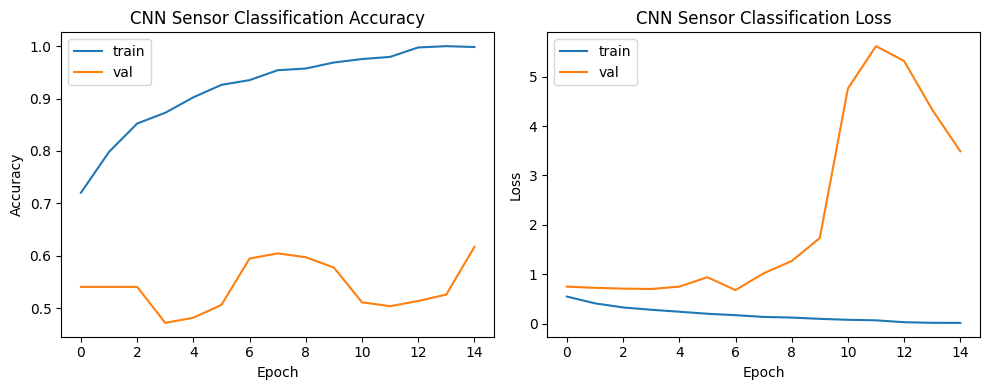

In [10]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history_cnn.history['accuracy'], label='train')
plt.plot(history_cnn.history['val_accuracy'], label='val')
plt.title('CNN Sensor Classification Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_cnn.history['loss'], label='train')
plt.plot(history_cnn.history['val_loss'], label='val')
plt.title('CNN Sensor Classification Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
CNN accuracy: 0.5945945945945946
              precision    recall  f1-score   support

    sensor_1       0.73      0.40      0.51       220
    sensor_2       0.54      0.83      0.65       187

    accuracy                           0.59       407
   macro avg       0.63      0.61      0.58       407
weighted avg       0.64      0.59      0.58       407



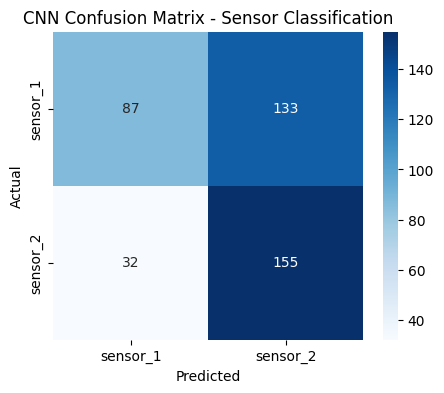

In [11]:
cnn_probs = cnn.predict(X_test)
cnn_pred = np.argmax(cnn_probs, axis=1)
cnn_acc = accuracy_score(y_test, cnn_pred)
print("CNN accuracy:", cnn_acc)
print(classification_report(y_test, cnn_pred, target_names=sensor_encoder.classes_))

cm = confusion_matrix(y_test, cnn_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sensor_encoder.classes_,
            yticklabels=sensor_encoder.classes_)
plt.title('CNN Confusion Matrix - Sensor Classification')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [12]:
resnet = build_resnet(X_train.shape[1:], len(np.unique(y)))
resnet.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 1000, 1)           │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_4 (Conv1D)             │ (None, 1000, 32)          │             256 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_4         │ (None, 1000, 32)          │             128 │ conv1d_4[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_5 (Conv1D)             │ (None, 1000, 32)          │           3,104 │ batch_normalization_4[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_5         │ (None, 1000, 32)          │             128 │ conv1d_5[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_6 (Conv1D)             │ (None, 1000, 32)          │           3,104 │ batch_normalization_5[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_6         │ (None, 1000, 32)          │             128 │ conv1d_6[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 1000, 32)          │               0 │ batch_normalization_6[0][… │
│                               │                           │                 │ batch_normalization_4[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation (Activation)       │ (None, 1000, 32)          │               0 │ add[0][0]                  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_7 (Conv1D)             │ (None, 1000, 64)          │           6,208 │ activation[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_7         │ (None, 1000, 64)          │             256 │ conv1d_7[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_8 (Conv1D)             │ (None, 1000, 64)          │          12,352 │ batch_normalization_7[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_8         │ (None, 1000, 64)          │             256 │ conv1d_8[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_9 (Conv1D)             │ (None, 1000, 64)          │           2,112 │ activation[0][0]           │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 227,714 (889.51 KB)

 Trainable params: 226,242 (883.76 KB)

 Non-trainable params: 1,472 (5.75 KB)

In [13]:
history_resnet = resnet.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/45
39/39 ━━━━━━━━━━━━━━━━━━━━ 29s 530ms/step - accuracy: 0.7080 - loss: 0.5784 - val_accuracy: 0.5405 - val_loss: 0.7218 - learning_rate: 0.0010
Epoch 2/45
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 508ms/step - accuracy: 0.7900 - loss: 0.4133 - val_accuracy: 0.5405 - val_loss: 1.3169 - learning_rate: 0.0010
Epoch 3/45
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 505ms/step - accuracy: 0.8376 - loss: 0.3536 - val_accuracy: 0.5405 - val_loss: 1.5674 - learning_rate: 0.0010
Epoch 4/45
39/39 ━━━━━━━━━━━━━━━━━━━━ 14s 365ms/step - accuracy: 0.8638 - loss: 0.3120 - val_accuracy: 0.5405 - val_loss: 1.5930 - learning_rate: 0.0010
Epoch 5/45
39/39 ━━━━━━━━━━━━━━━━━━━━ 13s 343ms/step - accuracy: 0.8893 - loss: 0.2650 - val_accuracy: 0.5405 - val_loss: 1.2513 - learning_rate: 5.0000e-04
Epoch 6/45
39/39 ━━━━━━━━━━━━━━━━━━━━ 14s 353ms/step - accuracy: 0.9073 - loss: 0.2274 - val_accuracy: 0.4914 - val_loss: 0.6398 - learning_rate: 5.0000e-04
Epoch 7/45
39/39 ━━━━━━━━━━━━━━━━━━━━ 14s 359ms/step - accuracy: 0.9303 - 

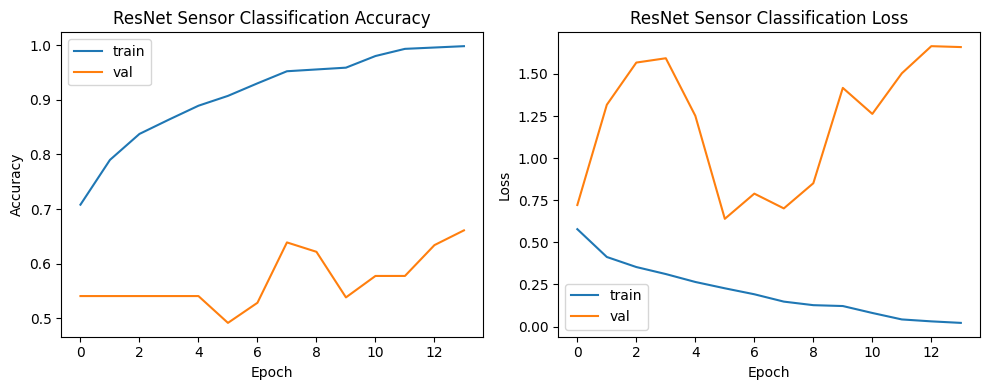

In [14]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history_resnet.history['accuracy'], label='train')
plt.plot(history_resnet.history['val_accuracy'], label='val')
plt.title('ResNet Sensor Classification Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_resnet.history['loss'], label='train')
plt.plot(history_resnet.history['val_loss'], label='val')
plt.title('ResNet Sensor Classification Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 137ms/step
ResNet accuracy: 0.4914004914004914
              precision    recall  f1-score   support

    sensor_1       0.53      0.55      0.54       220
    sensor_2       0.44      0.42      0.43       187

    accuracy                           0.49       407
   macro avg       0.49      0.49      0.49       407
weighted avg       0.49      0.49      0.49       407



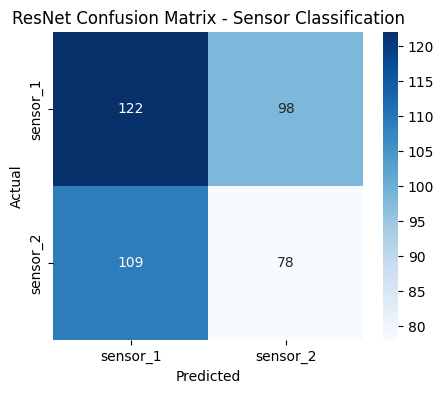

In [15]:
resnet_probs = resnet.predict(X_test)
resnet_pred = np.argmax(resnet_probs, axis=1)
resnet_acc = accuracy_score(y_test, resnet_pred)
print("ResNet accuracy:", resnet_acc)
print(classification_report(y_test, resnet_pred, target_names=sensor_encoder.classes_))

cm = confusion_matrix(y_test, resnet_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sensor_encoder.classes_,
            yticklabels=sensor_encoder.classes_)
plt.title('ResNet Confusion Matrix - Sensor Classification')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [16]:
results = pd.DataFrame([
    {"task":"sensor_classification", "split":"same_dataset", "model":"CNN", "frame":FRAME_LENGTH, "overlap":OVERLAP, "accuracy":cnn_acc},
    {"task":"sensor_classification", "split":"same_dataset", "model":"ResNet", "frame":FRAME_LENGTH, "overlap":OVERLAP, "accuracy":resnet_acc},
])
results.to_csv(f"sensor_classification_results_frame{FRAME_LENGTH}_overlap{int(OVERLAP*100)}.csv", index=False)
cnn.save(f"cnn_sensor_model_frame{FRAME_LENGTH}_overlap{int(OVERLAP*100)}.h5")
resnet.save(f"resnet_sensor_model_frame{FRAME_LENGTH}_overlap{int(OVERLAP*100)}.h5")
results

,task,split,model,frame,overlap,accuracy
0,sensor_classification,same_dataset,CNN,1000,0.5,0.594595
1,sensor_classification,same_dataset,ResNet,1000,0.5,0.491400
